<a href="https://colab.research.google.com/github/Plumz17/DL_Assignment01/blob/main/DL_Assignment01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#First Deep Learning Assignment - Single Layer Perceptron - Anders Emmanuel Tan (24/541351/PA/22964)
Replicates the manual gsheet SLP training using: sigmoid activation, LR=0.1, stochastic gradient descent, 5 epochs.

Google Sheet and full dataset can be seen here (copied from Bu Afia's template): https://docs.google.com/spreadsheets/d/1CgPq9_PMiXY4apCE4ctajTwHeQQzWcKJ/edit?usp=sharing&ouid=105574403098262346898&rtpof=true&sd=true

- Rows 1–80 (per epoch) = **training** (weights update after every row)
- Rows 81–100 = **validation** (weights frozen, forward pass only)

# 0. Data Acquision

In [44]:
# Imports
import math
import matplotlib.pyplot as plt
import pandas as pd

In [45]:
# Import data from github .csv file
CSV_URL = "https://raw.githubusercontent.com/Plumz17/DL_Assignment01/main/data.csv"
df = pd.read_csv(CSV_URL)
print(df.shape)
df.head()

(100, 5)


,X1,X2,X3,X4,target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [46]:
setosa = df[df['target'] == 0].reset_index(drop=True)
versicolor = df[df['target'] == 1].reset_index(drop=True)

df_ordered = pd.concat([
  # rows 1-40: Setosa (Training Data)
  setosa.head(40),
  # rows 41-80: Versicolor (Training Data)
  versicolor.head(40),
  # rows 81-90: Setosa (Validation Data)
  setosa.tail(10),
  # rows 91-100: Versicolor (Validation Data)
  versicolor.tail(10),
]).reset_index(drop=True)

data = df_ordered[['X1', 'X2', 'X3', 'X4', 'target']].values.tolist()

train = data[:80]
val = data[80:]
print(f'Train rows: {len(train)}, Validation rows: {len(val)}')

Train rows: 80, Validation rows: 20


# 1. Model Setup

In [47]:
# Initialize weights (and biases)
weights = {'b': 0.5, 'w1': 0.5, 'w2': 0.5, 'w3': 0.5, 'w4': 0.5}
learning_rate = 0.1

def sigmoid(z):
  return 1 / (1 + math.exp(-z))

def forward(x1, x2, x3, x4):
  z = weights['b'] + weights['w1']*x1 + weights['w2']*x2 + weights['w3']*x3 + weights['w4']*x4
  g = sigmoid(z)
  pred = 1 if g > 0.5 else 0
  return g, pred # probability and predicted value


# 2. Model Training

In [48]:
epochs = 5
results = []

for epoch in range(1, epochs+1):
  # Training
  sse_train = []
  tp = fp = tn = fn = 0
  for row in train:
    x1, x2, x3, x4, y = row
    g, pred = forward(x1, x2, x3, x4)
    err = g - y
    sse_train.append(err**2)
    if pred == 1 and y == 1: tp += 1
    elif pred == 1 and y == 0: fp += 1
    elif pred == 0 and y == 0: tn += 1
    elif pred == 0 and y == 1: fn += 1
    weights['b']  -= learning_rate * (2 * err * g * (1 - g)) * 1
    weights['w2'] -= learning_rate * (2 * err * g * (1 - g)) * x2
    weights['w1'] -= learning_rate * (2 * err * g * (1 - g)) * x1
    weights['w3'] -= learning_rate * (2 * err * g * (1 - g)) * x3
    weights['w4'] -= learning_rate * (2 * err * g * (1 - g)) * x4
  # Get Training Loss and Accuracy
  train_mse = sum(sse_train) / len(sse_train)
  train_acc = (tp + tn) / (tp + fp + tn + fn)

  # Validation
  sse_val = []
  vtp = vfp = vtn = vfn = 0
  for row in val:
    x1, x2, x3, x4, y = row
    g, pred = forward(x1, x2, x3, x4)
    err = g - y
    sse_val.append(err ** 2)

    if pred == 1 and y == 1: vtp += 1
    elif pred == 1 and y == 0: vfp += 1
    elif pred == 0 and y == 0: vtn += 1
    elif pred == 0 and y == 1: vfn += 1
  # Get Validation Loss and Accuracy
  val_mse = sum(sse_val) / len(sse_val)
  val_acc = (vtp + vtn) / (vtp + vfp + vtn + vfn)

  results.append({
    'epoch': epoch,
    'train_mse': train_mse, 'train_acc': train_acc, 'train_tp': tp, 'train_fp': fp, 'train_tn': tn, 'train_fn': fn,
    'val_mse': val_mse, 'val_acc': val_acc, 'val_tp': vtp, 'val_fp': vfp, 'val_tn': vtn, 'val_fn': vfn,
  })
  print(f"Epoch {epoch}: train_MSE={train_mse:.6f} train_acc={train_acc:.4f} val_MSE={val_mse:.6f} val_acc={val_acc:.4f}")

print('Final weights:', weights)

Epoch 1: train_MSE=0.449889 train_acc=0.5250 val_MSE=0.328951 val_acc=0.5000
Epoch 2: train_MSE=0.037452 train_acc=0.9500 val_MSE=0.247289 val_acc=0.5000
Epoch 3: train_MSE=0.024372 train_acc=0.9750 val_MSE=0.175892 val_acc=0.5000
Epoch 4: train_MSE=0.017357 train_acc=0.9750 val_MSE=0.119381 val_acc=0.8500
Epoch 5: train_MSE=0.012740 train_acc=0.9875 val_MSE=0.081581 val_acc=1.0000
Final weights: {'b': 0.2577197481284967, 'w1': -0.2418016548639205, 'w2': -0.4169034850498341, 'w3': 1.1222139008546288, 'w4': 0.8240586606921434}


# 3. Model Evaluation

In [49]:
results_df = pd.DataFrame(results)

print('MSE per Epoch (Training)')
print(results_df[['epoch', 'train_mse']].to_string(index=False))

print('\nAccuracy per Epoch (Training)')
print(results_df[['epoch', 'train_acc', 'train_tp', 'train_fp', 'train_tn', 'train_fn']].to_string(index=False))

print('\nMSE per Epoch (Validation)')
print(results_df[['epoch', 'val_mse']].to_string(index=False))

print('\nAccuracy per Epoch (Validation)')
print(results_df[['epoch', 'val_acc', 'val_tp', 'val_fp', 'val_tn', 'val_fn']].to_string(index=False))

MSE per Epoch (Training)
 epoch  train_mse
     1   0.449889
     2   0.037452
     3   0.024372
     4   0.017357
     5   0.012740

Accuracy per Epoch (Training)
 epoch  train_acc  train_tp  train_fp  train_tn  train_fn
     1     0.5250        39        37         3         1
     2     0.9500        38         2        38         2
     3     0.9750        39         1        39         1
     4     0.9750        39         1        39         1
     5     0.9875        39         0        40         1

MSE per Epoch (Validation)
 epoch  val_mse
     1 0.328951
     2 0.247289
     3 0.175892
     4 0.119381
     5 0.081581

Accuracy per Epoch (Validation)
 epoch  val_acc  val_tp  val_fp  val_tn  val_fn
     1     0.50      10      10       0       0
     2     0.50      10      10       0       0
     3     0.50      10      10       0       0
     4     0.85      10       3       7       0
     5     1.00      10       0      10       0


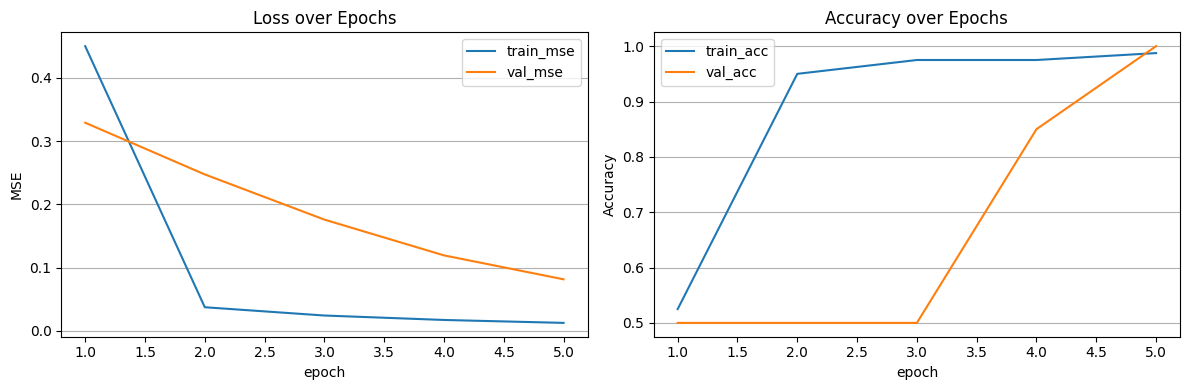

In [53]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

results_df.plot(x='epoch', y=['train_mse', 'val_mse'], ax=axes[0], title='Loss over Epochs')
results_df.plot(x='epoch', y=['train_acc', 'val_acc'], ax=axes[1], title='Accuracy over Epochs')

# Add grids to y axis
axes[0].grid(axis='y')
axes[1].grid(axis='y')

# Add Label to y aaxis
axes[0].set_ylabel('MSE')
axes[1].set_ylabel('Accuracy')

plt.show()